In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets,layers,losses,Model
from random import randint

In [2]:
(x_train,y_train),(x_test,y_test)=(tf.keras.datasets.mnist.load_data())
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0

In [3]:
noise_factor=0.4
x_train_noisy=x_train+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_train.shape)
x_test_noisy=x_test+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_test.shape)
x_train_noisy=np.clip(x_train_noisy,0.0,1.0)
x_test_noisy=np.clip(x_test_noisy,0.0,1.0)

In [4]:
# designing encoder
input_layer=layers.Input(shape=x_train.shape[1:])###(60000,28,28)
flattened=layers.Flatten()(input_layer)##784
hidden=layers.Dense(100,activation='relu')(flattened)
latent=layers.Dense(20,activation='relu')(hidden)
encoder=Model(inputs=input_layer,outputs=latent,name='encoder')
encoder.summary()


Model: "encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 100)               78500     
                                                                 
 dense_1 (Dense)             (None, 20)                2020      
                                                                 
Total params: 80520 (314.53 KB)
Trainable params: 80520 (314.53 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
#designing decoder
input_layer_decoder=layers.Input(shape=encoder.output.shape[1:])
upsampled1=layers.Dense(100,activation='relu')(input_layer_decoder)
upsampled2=layers.Dense(784,activation='relu')(upsampled1)
constructed=layers.Reshape(x_train.shape[1:])(upsampled2)
decoder=Model(inputs=input_layer_decoder,outputs=constructed,name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 20)]              0         
                                                                 
 dense_2 (Dense)             (None, 100)               2100      
                                                                 
 dense_3 (Dense)             (None, 784)               79184     
                                                                 
 reshape (Reshape)           (None, 28, 28)            0         
                                                                 
Total params: 81284 (317.52 KB)
Trainable params: 81284 (317.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
#designing autoencoder
autoencoder=Model(inputs=encoder.input,outputs=decoder(encoder.output))
autoencoder.summary()
autoencoder.compile(optimizer='adam',loss=losses.MeanSquaredError(),metrics=['accuracy'])
summary=autoencoder.fit(x_train_noisy,x_train,epochs=10,batch_size=32,validation_data=(x_test_noisy,x_test))

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 100)               78500     
                                                                 
 dense_1 (Dense)             (None, 20)                2020      
                                                                 
 decoder (Functional)        (None, 28, 28)            81284     
                                                                 
Total params: 161804 (632.05 KB)
Trainable params: 161804 (632.05 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

Epoch 1/10


1875/18

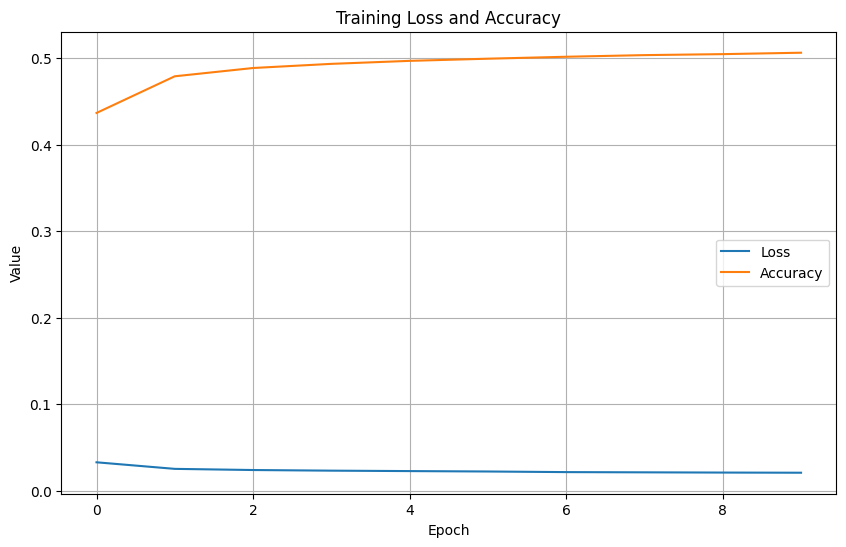

In [7]:
##plot graph of accuracy and loss of both training
plt.figure(figsize=(10, 6))
plt.plot(summary.history['loss'], label='Loss')
plt.plot(summary.history['accuracy'], label='Accuracy')
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

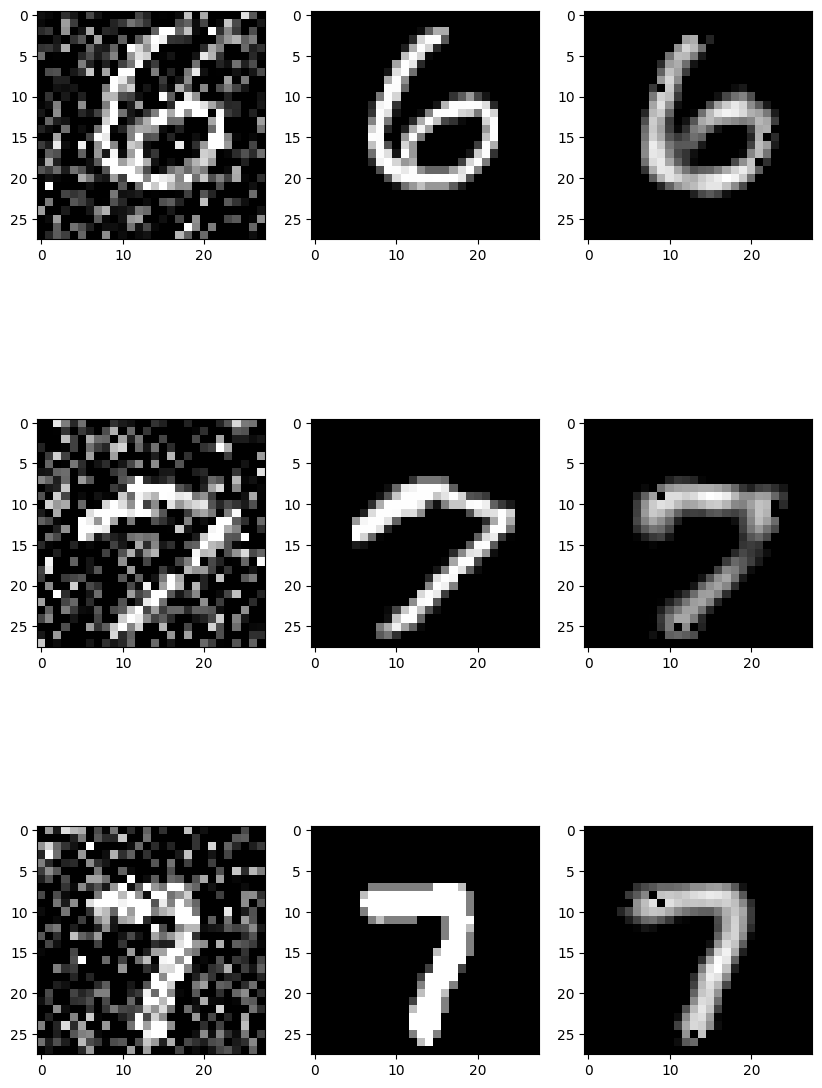

In [8]:
fig,axs=plt.subplots(3,3,figsize=(10,15))
for i in range(3):
    idx=randint(0,x_train_noisy.shape[0])
    sample=x_train[idx]
    noisy_sample=x_train_noisy[idx]
    axs[i][0].imshow(noisy_sample,cmap='gray')
    axs[i][1].imshow(sample, cmap='gray')
    axs[i][2].imshow(autoencoder(np.expand_dims(noisy_sample,axis=0))[0],cmap='gray')
plt.show()